In [33]:
# Notebook Training - Plant Health Analysis
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score, recall_score,
                             roc_curve, auc, RocCurveDisplay)
from sklearn.preprocessing import label_binarize
from itertools import cycle
import warnings
warnings.filterwarnings('ignore')

print("="*50)
print("SVM MODEL TRAINING")
print("3-Class Classification - SVM with RBF Kernel")
print("Classes: 0=Healthy | 1=Moderate Stress | 2=High Stress")
print("="*50)

SVM MODEL TRAINING
3-Class Classification - SVM with RBF Kernel
Classes: 0=Healthy | 1=Moderate Stress | 2=High Stress


In [34]:
# 1. LOAD TRAINING DATA
print("\n1. LOADING TRAINING DATA")
print("-"*50)
train_df = pd.read_csv('../data/processed/train_data.csv')
print(f"✓ Training data loaded: {train_df.shape}")

# Load preprocessing objects
with open('../model/preprocessing_objects.pkl', 'rb') as f:
    preprocessing_objects = pickle.load(f)

label_encoder = preprocessing_objects['label_encoder']
feature_columns = preprocessing_objects['feature_columns']
print(f"✓ Preprocessing objects loaded")
print(f"✓ Classes: {list(label_encoder.classes_)}")

# Prepare X and y
X_train = train_df[feature_columns].values
y_train = train_df['Plant_Health_Status'].values

print(f"✓ X_train shape: {X_train.shape}")
print(f"✓ y_train shape: {y_train.shape}")
print(f"✓ Unique classes in y_train: {np.unique(y_train)}")


1. LOADING TRAINING DATA
--------------------------------------------------
✓ Training data loaded: (960, 15)
✓ Preprocessing objects loaded
✓ Classes: [np.str_('Healthy'), np.str_('High Stress'), np.str_('Moderate Stress')]
✓ X_train shape: (960, 14)
✓ y_train shape: (960,)
✓ Unique classes in y_train: [0 1 2]


In [35]:
# 2. DEFINE SVM MODEL
print("\n2. DEFINING SVM MODEL")
print("-"*50)

svm_model = SVC(
    kernel='rbf',
    C=0.5,
    gamma='scale',
    random_state=42,
    probability=True,
    class_weight='balanced'
)

print("✓ SVM model defined with parameters:")
print(f"  - Kernel: rbf")
print(f"  - C: 0.5")
print(f"  - Gamma: scale")
print(f"  - Class weight: balanced")
print(f"  - Probability: True")


2. DEFINING SVM MODEL
--------------------------------------------------
✓ SVM model defined with parameters:
  - Kernel: rbf
  - C: 0.5
  - Gamma: scale
  - Class weight: balanced
  - Probability: True


In [36]:
# 3. CROSS-VALIDATION
print("\n3. CROSS-VALIDATION (5-FOLD)")
print("-" * 50)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring_metrics = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']
cv_results = {}

for metric in scoring_metrics:
    cv_scores = cross_val_score(svm_model, X_train, y_train, cv=cv,
                                scoring=metric, n_jobs=-1)
    cv_results[metric] = {
        'mean': cv_scores.mean(),
        'std': cv_scores.std(),
        'scores': cv_scores
    }
    print(f"✓ {metric}: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


3. CROSS-VALIDATION (5-FOLD)
--------------------------------------------------
✓ accuracy: 0.7979 (+/- 0.0315)
✓ f1_weighted: 0.7983 (+/- 0.0320)
✓ precision_weighted: 0.8035 (+/- 0.0313)
✓ recall_weighted: 0.7979 (+/- 0.0315)


In [37]:
# 4. FINAL SVM TRAINING
print("\n4. FINAL SVM TRAINING")
print("-"*50)

print("Training SVM model on the entire training set...")
svm_model.fit(X_train, y_train)
print("✓ SVM model trained successfully")

# Predictions on the training set
y_train_pred = svm_model.predict(X_train)

# Compute metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')

print(f"✓ Training set performance:")
print(f"  - Accuracy: {train_accuracy:.4f}")
print(f"  - F1-Score: {train_f1:.4f}")
print(f"  - Precision: {train_precision:.4f}")
print(f"  - Recall: {train_recall:.4f}")


4. FINAL SVM TRAINING
--------------------------------------------------
Training SVM model on the entire training set...
✓ SVM model trained successfully
✓ Training set performance:
  - Accuracy: 0.9094
  - F1-Score: 0.9098
  - Precision: 0.9140
  - Recall: 0.9094



5. DETAILED PERFORMANCE ANALYSIS
--------------------------------------------------

Classification report (Training Set):
                 precision    recall  f1-score   support

        Healthy       0.88      0.97      0.92       239
    High Stress       0.98      0.88      0.92       400
Moderate Stress       0.86      0.91      0.88       321

       accuracy                           0.91       960
      macro avg       0.91      0.92      0.91       960
   weighted avg       0.91      0.91      0.91       960


✓ Confusion matrix saved: model/svm_confusion_matrix_train.png


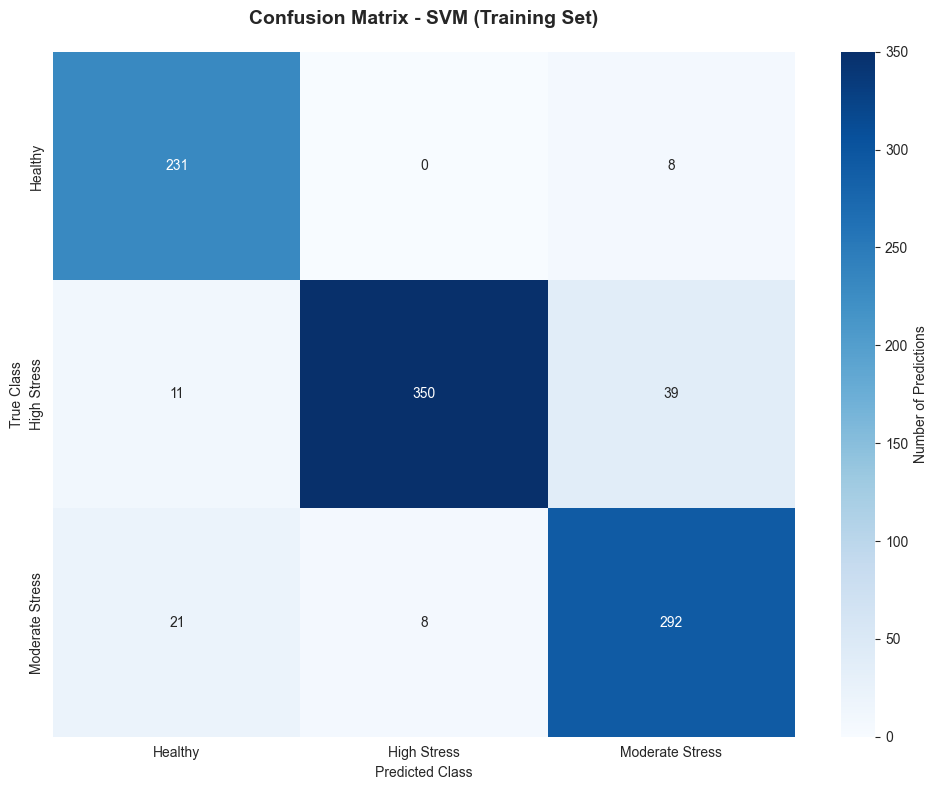

In [38]:
# 5. DETAILED PERFORMANCE ANALYSIS
print("\n5. DETAILED PERFORMANCE ANALYSIS")
print("-"*50)

print("\nClassification report (Training Set):")
print(classification_report(y_train, y_train_pred,
                          target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Number of Predictions'})
plt.title('Confusion Matrix - SVM (Training Set)',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig('../model/svm_confusion_matrix_train.png', dpi=300, bbox_inches='tight')
print("\n✓ Confusion matrix saved: model/svm_confusion_matrix_train.png")
plt.show()


6. MULTICLASS ROC CURVES
--------------------------------------------------
✓ ROC curves saved: model/svm_roc_curves.png


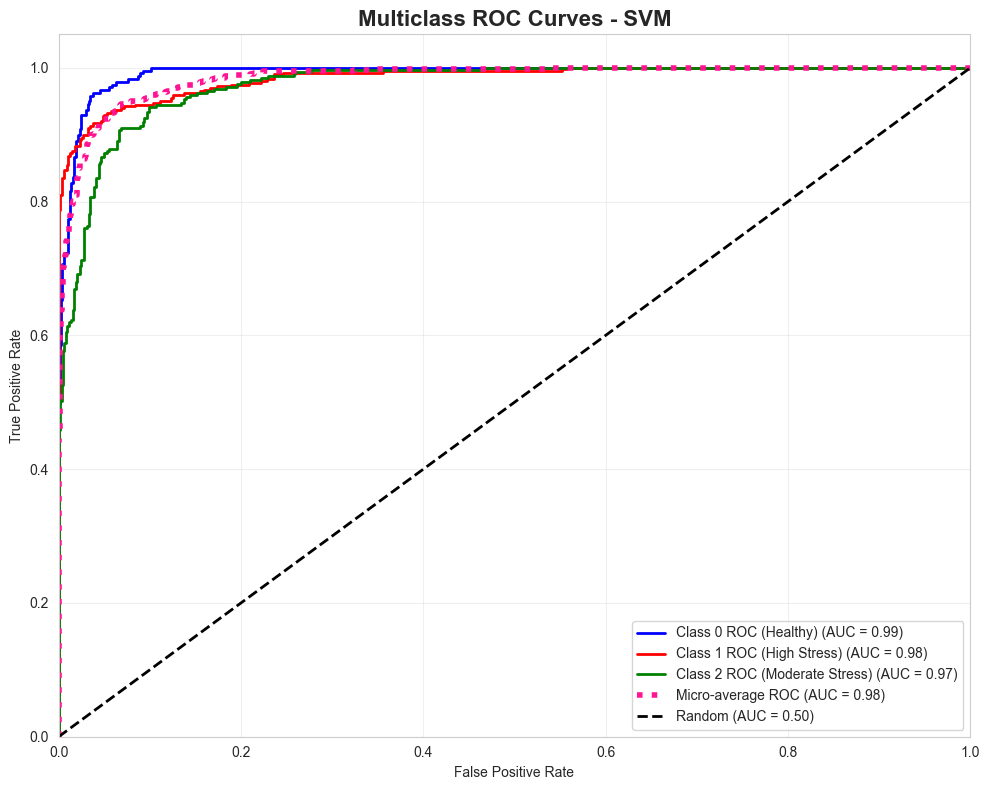


✓ AUC for each class:
  - Class 0 (Healthy): 0.9923
  - Class 1 (High Stress): 0.9848
  - Class 2 (Moderate Stress): 0.9747
  - Micro-average: 0.9847


In [39]:
# 6. MULTICLASS ROC CURVES
print("\n6. MULTICLASS ROC CURVES")
print("-"*50)

y_train_proba = svm_model.predict_proba(X_train)
n_classes = len(label_encoder.classes_)

y_train_bin = label_binarize(y_train, classes=[0, 1, 2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_train_bin[:, i], y_train_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_train_bin.ravel(), y_train_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='Class {0} ROC ({1}) (AUC = {2:0.2f})'
             .format(i, label_encoder.classes_[i], roc_auc[i]))

plt.plot(fpr["micro"], tpr["micro"],
         label='Micro-average ROC (AUC = {0:0.2f})'.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves - SVM', fontsize=16, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../model/svm_roc_curves.png', dpi=300, bbox_inches='tight')
print("✓ ROC curves saved: model/svm_roc_curves.png")
plt.show()

print("\n✓ AUC for each class:")
for i in range(n_classes):
    print(f"  - Class {i} ({label_encoder.classes_[i]}): {roc_auc[i]:.4f}")
print(f"  - Micro-average: {roc_auc['micro']:.4f}")


7. DECISION SCORES ANALYSIS
--------------------------------------------------
✓ Decision scores obtained:
  Shape: (960, 3)
✓ Score distribution saved: model/svm_decision_scores.png


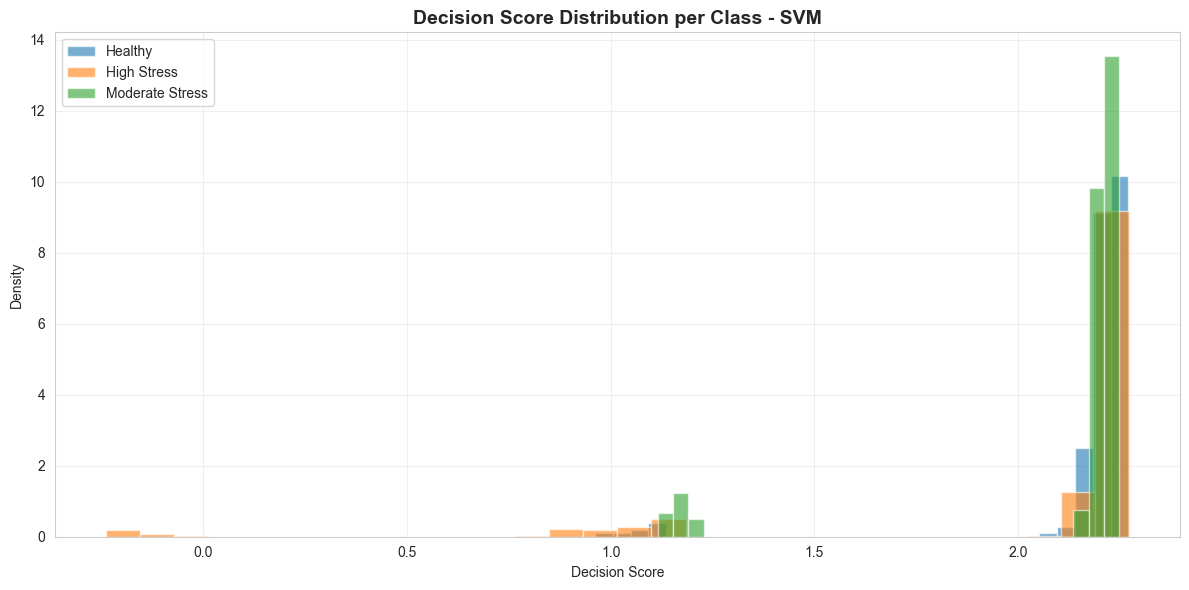

In [40]:
# 7. DECISION SCORES ANALYSIS
print("\n7. DECISION SCORES ANALYSIS")
print("-"*50)

y_decision_scores = svm_model.decision_function(X_train)

print("✓ Decision scores obtained:")
print(f"  Shape: {y_decision_scores.shape}")

plt.figure(figsize=(12, 6))
for i, class_name in enumerate(label_encoder.classes_):
    class_scores = y_decision_scores[y_train == i, i]
    plt.hist(class_scores, bins=30, alpha=0.6, label=f'{class_name}', density=True)

plt.xlabel('Decision Score')
plt.ylabel('Density')
plt.title('Decision Score Distribution per Class - SVM', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../model/svm_decision_scores.png', dpi=300, bbox_inches='tight')
print("✓ Score distribution saved: model/svm_decision_scores.png")
plt.show()

In [41]:
# 8. SAVE MODEL AND RESULTS
print("\n8. SAVE MODEL AND RESULTS")
print("-"*50)

model_path = '../model/svm_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(svm_model, f)
print(f"✓ SVM model saved: {model_path}")

training_results = {
    'train_metrics': {
        'accuracy': train_accuracy,
        'f1_score': train_f1,
        'precision': train_precision,
        'recall': train_recall
    },
    'cv_metrics': cv_results,
    'roc_auc': roc_auc,
    'feature_columns': feature_columns,
    'label_encoder': label_encoder
}

results_path = '../model/svm_training_results.pkl'
with open(results_path, 'wb') as f:
    pickle.dump(training_results, f)
print(f"✓ Training results saved: {results_path}")


8. SAVE MODEL AND RESULTS
--------------------------------------------------
✓ SVM model saved: ../model/svm_model.pkl
✓ Training results saved: ../model/svm_training_results.pkl
